# ESERCIZIO 2.2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import fmfinance as fm
import plotly.io as pio
import quantstats as qs
import time
import random
import plotly.express as px
import warnings
from yfinance import Search # importo questo pacchetto per trovare le proxy deu quattro fattori europei da yfinance e non da FamaFrench

# statsmodels
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.iolib.summary2 import summary_col
from statsmodels.datasets import longley

# scipy
from scipy.stats import norm
from scipy.stats import linregress
from scipy import stats

# datetime e pandas utils
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# PyPortfolioOpt (Es02)
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# Widget e display (Es02b, Es04b)
import ipywidgets as widgets
from IPython.display import display

# Web scraping (Es03c)
import requests
from bs4 import BeautifulSoup
from io import StringIO

# Soppressione warning
warnings.filterwarnings("ignore", category=FutureWarning)

## PUNTO 1

In [2]:
# importiamo il DataSet con tutti i ticker del NASDAQ
ixic = pd.read_csv('ixic.csv')
ixic.head(5)

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
0,AACB,Artius II Acquisition Inc. Class A Ordinary Sh...,$10.43,0.0000,0.00%,0.0,United States,2025.0,6,NaN,NaN
1,AACG,ATA Creativity Global American Depositary Shares,$1.1899,-0.0001,-0.008%,51201393.0,China,2008.0,5635,Real Estate,Other Consumer Services
2,AACI,Armada Acquisition Corp. III Class A Ordinary ...,$9.935,0.0050,0.05%,0.0,United States,2026.0,533,NaN,NaN
3,AACIU,Armada Acquisition Corp. III Units,$10.08,0.0000,0.00%,0.0,United States,2026.0,41,Finance,Blank Checks
4,AACIW,Armada Acquisition Corp. III Warrant,$0.22,-0.0200,-8.333%,0.0,United States,2026.0,10941,NaN,NaN


In [3]:
# estraiamo 300 titoli a caso (con esperimento pilotato)
random.seed(31415)
random_tickers  = random.sample(list(ixic['Symbol']),300)
random_tickers

['NAVI',
 'SIDU',
 'EJH',
 'VSEE',
 'TVRD',
 'INNV',
 'ALGT',
 'MDAIW',
 'LSCC',
 'VECO',
 'HVMC',
 'BMBL',
 'QNCX',
 'OSRHW',
 'SNDL',
 'RCON',
 'GOVX',
 'HIT',
 'CELH',
 'JXG',
 'KYNB',
 'HCAI',
 'ALXO',
 'SNT',
 'PAL',
 'REPL',
 'COLAR',
 'NVCR',
 'PCT',
 'VCYT',
 'WAVE',
 'BGLC',
 'GANX',
 'ADSE',
 'TACT',
 'ECX',
 'LWAC',
 'LPAAW',
 'POWWP',
 'PAA',
 'SATA',
 'JBSS',
 'VHUB',
 'RDHL',
 'DAVEW',
 'LMB',
 'IGIC',
 'UG',
 'OPRA',
 'DKI',
 'OMAB',
 'SVIVU',
 'RNGT',
 'OCUL',
 'DMAAU',
 'HCAT',
 'ZBRA',
 'CODX',
 'FGBIP',
 'IEAGR',
 'RLAY',
 'EZRA',
 'DYOR',
 'APLM',
 'TEAM',
 'NDAQ',
 'FFAIW',
 'CPZ',
 'TRVI',
 'RIME',
 'LFMD',
 'OCCIM',
 'EEFT',
 'ATHR',
 'ADTX',
 'CEPS',
 'CYCN',
 'DHCNL',
 'TRDA',
 'NCRA',
 'VISN',
 'ILAG',
 'AZ',
 'VEEE',
 'LINC',
 'CRWS',
 'INDI',
 'BAFN',
 'RGS',
 'BHAVR',
 'NXTT',
 'BLUW',
 'JDZG',
 'XNDU',
 'NNBR',
 'RIOT',
 'AACIW',
 'FSUN',
 'DXCM',
 'ALAB',
 'FOX',
 'TOI',
 'SGML',
 'IRMD',
 'RDGT',
 'WINA',
 'OFAL',
 'ACAA',
 'PMAX',
 'TPST',
 'VTVT',
 'KN

In [4]:
# scarichiamo i prezzi mensili dal 2017 al 2025 dei 300 titoli estratti
start = '2017-01-01'
end   = '2025-12-31'

prices = yf.download(random_tickers, start,end,auto_adjust=False, multi_level_index=False, interval='1mo')['Adj Close']
prices = prices.dropna(axis=1, how='all') 
# con how all elimino le colonne che non hanno nemmeno un'osservazione, se in una colonna abbiamo un osservazione quella rimane
# se non scriviamo niente è l'equivalente di dire how=any, quindi basta che ci sia una sola cella vuota e l'intera colonna salta
# quando passiamo il dataframe a bootstrap, la funzione controlla quante osservazioni valide ha ogni titolo. se ne ha meno di 36 (mesi) lo scarta automaticamente.
prices

[*                      3%                       ]  10 of 300 completed$ACAA: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1767157200")
[**                     4%                       ]  11 of 300 completed$COLAR: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31)
[***                    6%                       ]  18 of 300 completed$MKDWW: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1767157200")
[*****                 10%                       ]  31 of 300 completed$GTENW: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1767157200")
[******                13%                       ]  39 of 300 completed$AACIW: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-

Ticker,ACIW,ACOG,ADSE,ADTX,AGEN,ALAB,ALDFU,ALGT,ALKT,ALM,...,WW,WYHG,XBP,XENE,XLO,YHGJ,YYGH,ZBRA,ZEO,ZKIN
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,19.400000,NaN,NaN,NaN,78.508339,NaN,NaN,155.992630,NaN,0.49050,...,NaN,NaN,NaN,8.200000,NaN,58.500000,NaN,83.669998,NaN,NaN
2017-02-01,19.570000,NaN,NaN,NaN,83.218842,NaN,NaN,157.897156,NaN,0.47250,...,NaN,NaN,NaN,8.050000,NaN,61.200001,NaN,90.709999,NaN,NaN
2017-03-01,21.389999,NaN,NaN,NaN,73.994110,NaN,NaN,145.336121,NaN,0.47250,...,NaN,NaN,NaN,4.000000,NaN,57.099998,NaN,91.250000,NaN,NaN
2017-04-01,21.490000,NaN,NaN,NaN,70.461235,NaN,NaN,132.400482,NaN,0.39825,...,NaN,NaN,NaN,3.950000,NaN,58.799999,NaN,94.269997,NaN,NaN
2017-05-01,22.860001,NaN,NaN,NaN,65.161926,NaN,NaN,124.751495,NaN,0.41625,...,NaN,NaN,NaN,3.650000,NaN,58.700001,NaN,104.339996,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,49.349998,8.30,12.98,25140.240234,4.180000,182.199997,10.50,62.660000,25.600000,4.45000,...,31.889999,1.440,6.04,38.709999,9.800,6.100000,128.000000,317.089996,1.65,1.97
2025-09-01,52.770000,6.51,12.00,18354.816406,3.850000,195.800003,10.75,60.770000,24.840000,6.03000,...,27.360001,1.290,8.07,40.150002,11.802,4.500000,18.549999,297.160004,1.35,2.20
2025-10-01,47.630001,6.19,11.42,1440.072021,3.970000,186.679993,10.75,62.180000,20.290001,7.13000,...,34.820000,1.030,5.91,41.919998,11.158,5.240000,15.550000,269.250000,1.75,2.44


In [5]:
# trasformiamo i prezzi in rendimenti, ed eliminiamo la prima riga del dataframe (non c'è un mese precedente)
returns= prices.pct_change()*100
returns = returns.dropna(how='all')
returns

Ticker,ACIW,ACOG,ADSE,ADTX,AGEN,ALAB,ALDFU,ALGT,ALKT,ALM,...,WW,WYHG,XBP,XENE,XLO,YHGJ,YYGH,ZBRA,ZEO,ZKIN
Date,,,,,,,,,,,,,,,,,,,,,
2017-02-01,0.876289,NaN,NaN,NaN,6.000003,NaN,NaN,1.220908,NaN,-3.669726,...,NaN,NaN,NaN,-1.829264,NaN,4.615386,NaN,8.414009,NaN,NaN
2017-03-01,9.299947,NaN,NaN,NaN,-11.084907,NaN,NaN,-7.955200,NaN,0.000000,...,NaN,NaN,NaN,-50.310560,NaN,-6.699350,NaN,0.595305,NaN,NaN
2017-04-01,0.467510,NaN,NaN,NaN,-4.774536,NaN,NaN,-8.900498,NaN,-15.714282,...,NaN,NaN,NaN,-1.249999,NaN,2.977234,NaN,3.309585,NaN,NaN
2017-05-01,6.375062,NaN,NaN,NaN,-7.520885,NaN,NaN,-5.777159,NaN,4.519768,...,NaN,NaN,NaN,-7.594935,NaN,-0.170065,NaN,10.682083,NaN,NaN
2017-06-01,-2.143481,NaN,NaN,NaN,17.771081,NaN,NaN,-0.538051,NaN,1.081082,...,NaN,NaN,NaN,-13.698630,NaN,-3.236800,NaN,-3.661108,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,15.953940,-8.891323,1.011667,-5.504589,-24.275365,33.255323,-0.943400,21.340048,14.849705,20.596199,...,-24.627751,24.137940,-53.178293,26.751794,7.858240,-11.594206,5.785124,-6.468643,-33.198382,-8.372096
2025-09-01,6.930095,-21.566264,-7.550074,-26.990290,-7.894735,7.464328,2.380952,-3.016277,-2.968751,35.505629,...,-14.205076,-10.416673,33.609267,3.719975,20.428570,-26.229507,-85.507813,-6.285280,-18.181816,11.675128
2025-10-01,-9.740382,-4.915517,-4.833333,-92.154255,3.116886,-4.657819,0.000000,2.320224,-18.317227,18.242121,...,27.266078,-20.155039,-26.765798,4.408460,-5.456703,16.444439,-16.172502,-9.392248,29.629627,10.909091


In [6]:
# scarichiamo dalla french data library i tre fattori di Fama-French mensili
factors   = fm.ff('F-F_Research_Data_Factors', start, end)[0]
factors

,Mkt-RF,SMB,HML,RF
Date,,,,
2017-01-01,1.94,-1.16,-2.76,0.04
2017-02-01,3.55,-2.15,-1.50,0.04
2017-03-01,0.17,1.13,-3.33,0.03
2017-04-01,1.08,0.66,-2.05,0.05
2017-05-01,1.07,-2.52,-3.82,0.06
...,...,...,...,...
2025-08-01,1.84,3.80,4.46,0.38
2025-09-01,3.39,-1.90,-0.94,0.33
2025-10-01,1.96,-0.82,-2.80,0.37


In [7]:
# sottraiamo il tasso risk-free da ogni colonna dei rendimenti
exc_returns = returns.subtract(factors['RF'], axis=0)
exc_returns

Ticker,ACIW,ACOG,ADSE,ADTX,AGEN,ALAB,ALDFU,ALGT,ALKT,ALM,...,WW,WYHG,XBP,XENE,XLO,YHGJ,YYGH,ZBRA,ZEO,ZKIN
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-01,0.836289,NaN,NaN,NaN,5.960003,NaN,NaN,1.180908,NaN,-3.709726,...,NaN,NaN,NaN,-1.869264,NaN,4.575386,NaN,8.374009,NaN,NaN
2017-03-01,9.269947,NaN,NaN,NaN,-11.114907,NaN,NaN,-7.985200,NaN,-0.030000,...,NaN,NaN,NaN,-50.340560,NaN,-6.729350,NaN,0.565305,NaN,NaN
2017-04-01,0.417510,NaN,NaN,NaN,-4.824536,NaN,NaN,-8.950498,NaN,-15.764282,...,NaN,NaN,NaN,-1.299999,NaN,2.927234,NaN,3.259585,NaN,NaN
2017-05-01,6.315062,NaN,NaN,NaN,-7.580885,NaN,NaN,-5.837159,NaN,4.459768,...,NaN,NaN,NaN,-7.654935,NaN,-0.230065,NaN,10.622083,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,15.573940,-9.271323,0.631667,-5.884589,-24.655365,32.875323,-1.323400,20.960048,14.469705,20.216199,...,-25.007751,23.757940,-53.558293,26.371794,7.478240,-11.974206,5.405124,-6.848643,-33.578382,-8.752096
2025-09-01,6.600095,-21.896264,-7.880074,-27.320290,-8.224735,7.134328,2.050952,-3.346277,-3.298751,35.175629,...,-14.535076,-10.746673,33.279267,3.389975,20.098570,-26.559507,-85.837813,-6.615280,-18.511816,11.345128
2025-10-01,-10.110382,-5.285517,-5.203333,-92.524255,2.746886,-5.027819,-0.370000,1.950224,-18.687227,17.872121,...,26.896078,-20.525039,-27.135798,4.038460,-5.826703,16.074439,-16.542502,-9.762248,29.259627,10.539091


In [8]:
# mettiamo in un dataframe i fattori e gli excess returns di tutti i titoli
data = pd.concat([factors, exc_returns], axis=1)
data.drop('RF',axis=1,inplace=True)
data

,Mkt-RF,SMB,HML,ACIW,ACOG,ADSE,ADTX,AGEN,ALAB,ALDFU,...,WW,WYHG,XBP,XENE,XLO,YHGJ,YYGH,ZBRA,ZEO,ZKIN
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,1.94,-1.16,-2.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-01,3.55,-2.15,-1.50,0.836289,NaN,NaN,NaN,5.960003,NaN,NaN,...,NaN,NaN,NaN,-1.869264,NaN,4.575386,NaN,8.374009,NaN,NaN
2017-03-01,0.17,1.13,-3.33,9.269947,NaN,NaN,NaN,-11.114907,NaN,NaN,...,NaN,NaN,NaN,-50.340560,NaN,-6.729350,NaN,0.565305,NaN,NaN
2017-04-01,1.08,0.66,-2.05,0.417510,NaN,NaN,NaN,-4.824536,NaN,NaN,...,NaN,NaN,NaN,-1.299999,NaN,2.927234,NaN,3.259585,NaN,NaN
2017-05-01,1.07,-2.52,-3.82,6.315062,NaN,NaN,NaN,-7.580885,NaN,NaN,...,NaN,NaN,NaN,-7.654935,NaN,-0.230065,NaN,10.622083,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,1.84,3.80,4.46,15.573940,-9.271323,0.631667,-5.884589,-24.655365,32.875323,-1.323400,...,-25.007751,23.757940,-53.558293,26.371794,7.478240,-11.974206,5.405124,-6.848643,-33.578382,-8.752096
2025-09-01,3.39,-1.90,-0.94,6.600095,-21.896264,-7.880074,-27.320290,-8.224735,7.134328,2.050952,...,-14.535076,-10.746673,33.279267,3.389975,20.098570,-26.559507,-85.837813,-6.615280,-18.511816,11.345128
2025-10-01,1.96,-0.82,-2.80,-10.110382,-5.285517,-5.203333,-92.524255,2.746886,-5.027819,-0.370000,...,26.896078,-20.525039,-27.135798,4.038460,-5.826703,16.074439,-16.542502,-9.762248,29.259627,10.539091


In [9]:
# teniamo il periodo completo in full_data e all'interno di data mettiamo la parte in sample
full_data = data.loc['2017-01-01':'2025-12-31']
data = full_data.loc['2017-01-01':'2022-12-31']

## PUNTO 2 

In [10]:
# Questo è il metodo che compare nell'esercitazione 4b, sulla parte in md intitolata bootstrap full sample (senza ribilanciamento)
# l'idea quì è che stiamo applicando il bootstrap sull'intero campione senza walk-forward e passiamo tutti i dati in una sola chiamata
n_factors = 3

np.random.seed(42)

alpha_obs, alpha_t_obs, alphas_boot, t_alphas_boot = fm.bootstrap(
    data.iloc[:, :n_factors],    # fattori: Mkt-RF, SMB, HML
    data.iloc[:, n_factors:],    # excess returns dei titoli
    n_boot=1000,
    min_obs=36
)

In [11]:
# siamo partiti da 300 titoli e ne abbiamo ottenuto 153 questo perchè abbiamo imposto una limitazione di 36 mensilità
# da questo momento in poi questo è il numero di titoli su cui lavoreremo 
# nella tabella ogni numero risponde alla domanda: "il rendimento di questo titolo, al netto dei tre fattori di rischio, è sistematicamente diverso da 0?"
# Un valore attorno a +/- 1.65 è la soglia classica OLS al 5%. tuttavia questa soglia da sola non basta
print(len(alpha_obs))
alpha_t_obs

153


ACIW   -0.257548
AGEN    0.102793
ALGT   -1.293658
ALM     0.776920
APPS    1.984495
          ...   
WVVI   -0.439316
XENE    1.229402
YHGJ   -0.062481
ZBRA    0.845841
ZKIN   -0.946728
Length: 153, dtype: float64

In [12]:
# Le colonne rappresentano posizioni in classifica
luck_d = pd.DataFrame((np.sort(np.array(t_alphas_boot))))
luck_d.index = [f"sim_{i+1}" for i in range(len(luck_d))]
luck_d

,0,1,2,3,4,5,6,7,8,9,...,143,144,145,146,147,148,149,150,151,152
sim_1,-3.971084,-3.364290,-2.414337,-2.318741,-2.291999,-2.153982,-2.139522,-1.965155,-1.852087,-1.829802,...,1.279275,1.440006,1.450168,1.635623,1.674903,1.772612,1.825431,1.945935,1.946926,2.493513
sim_2,-6.412131,-2.745093,-2.378559,-2.020436,-1.898267,-1.804727,-1.764719,-1.722151,-1.657893,-1.656004,...,1.584459,1.593757,1.615372,1.616490,1.727644,1.800987,1.819974,1.840707,1.990244,2.089639
sim_3,-3.546986,-2.956025,-2.432968,-2.349064,-2.281410,-1.801094,-1.793280,-1.771583,-1.732941,-1.681647,...,1.432811,1.550251,1.561430,1.620255,1.625803,1.649622,1.754734,1.796169,1.849092,1.992199
sim_4,-4.339682,-3.706091,-3.094813,-2.617495,-2.449379,-2.205282,-2.073331,-2.071605,-1.819382,-1.799956,...,1.559435,1.598162,1.598296,1.615143,1.658333,1.695250,1.719747,1.812594,1.892881,2.679578
sim_5,-5.769093,-4.515666,-2.721827,-2.577708,-2.571169,-2.369400,-2.296178,-2.288365,-2.249751,-2.207673,...,2.115659,2.192031,2.287490,2.345604,2.402067,2.534269,2.565272,2.886597,3.104908,3.245915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sim_996,-4.088560,-3.194850,-2.548028,-2.431095,-2.309789,-2.276902,-2.215055,-2.142299,-2.067804,-1.764533,...,1.716285,1.823506,1.842462,1.927405,1.942087,1.957653,1.989306,2.136064,2.255499,3.086033
sim_997,-4.884758,-4.106931,-3.658089,-3.187120,-2.625225,-2.582748,-2.287444,-2.111556,-1.999458,-1.702270,...,1.477853,1.604723,1.637197,1.700783,1.732568,1.769957,1.851989,2.178505,2.589145,2.809710
sim_998,-2.474705,-2.037258,-1.900672,-1.763731,-1.682706,-1.527846,-1.368205,-1.317010,-1.256933,-1.182250,...,1.597841,1.610050,1.658330,1.736550,1.797113,1.936506,1.936801,2.053673,2.201287,2.636033
sim_999,-3.059196,-2.848826,-2.375715,-2.329046,-2.170213,-1.985194,-1.979700,-1.845921,-1.785869,-1.769216,...,1.360281,1.404841,1.443902,1.521053,1.563002,1.739297,1.877353,1.911587,2.043183,2.138563


In [13]:
# Ordina i t-alpha reali dal peggiore al migliore
# ogni titolo acquisisce un rango che corrisponde alla stessa colonna di luck_d
sorted_original = pd.DataFrame(alpha_t_obs.sort_values(ascending=True))

# Per ogni rango, calcola il 95° percentile delle 1000 simulazioni
# → è la soglia massima ottenibile per pura fortuna a quella posizione in classifica
perc95 = pd.DataFrame(np.percentile(luck_d.T, 95, axis=1)).set_index(sorted_original.index)

# Un titolo è SKILLED solo se supera entrambe le condizioni:
# 1) il suo t-alpha reale batte la soglia di fortuna del suo rango
# 2) l'alpha è positivo
luck_sig = (sorted_original.iloc[:, 0] > perc95.iloc[:, 0]) & (sorted_original.iloc[:, 0] > 0)
skilled_list = sorted_original[luck_sig]

print(f"Fondi identificati come SKILLED (Luck Distribution): {len(skilled_list)}")
skilled_list.sort_values(by=skilled_list.columns[0], ascending=False)

# Estrazione lista ticker skilled → usata nel Punto 4 per costruire il portafoglio
skilled_tickers = skilled_list.index.tolist()
skilled_tickers

Fondi identificati come SKILLED (Luck Distribution): 21


['ELSE',
 'SILC',
 'TZOO',
 'GREE',
 'SPRO',
 'PRTH',
 'AGEN',
 'ICUI',
 'CIVB',
 'PETS',
 'AROW',
 'IMOS',
 'CCNE',
 'RIME',
 'MAR',
 'SANM',
 'JBSS',
 'VERI',
 'LSCC',
 'SITM',
 'APPS']

In [14]:
# Test OLS classico: titoli con t-alpha > 1.645 (soglia normale al 95%)
# → ignora il problema dei test multipli su un campione ampio
ols_sig = sorted_original.iloc[:, 0] > norm.ppf(0.95)

# Confronto tra i due metodi di selezione:
# CONFERMATI → skilled per entrambi i metodi: vera abilità
# DROPOUTS   → significativi OLS ma non luck dist: erano solo fortunati
# ADDITIONS  → non significativi OLS ma skilled luck dist: abilità sottovalutata
confermati = (ols_sig == True) & (luck_sig == True)
dropouts = (ols_sig == True) & (luck_sig == False)
additions = (ols_sig == False) & (luck_sig == True)

print("--- COMPARISON: OLS vs LUCK DISTRIBUTION ---")
print(f"Significativi OLS classici:  {ols_sig.sum()}")
print(f"Significativi Luck Dist:    {luck_sig.sum()}")
print("-" * 40)
print(f"CONFERMATI:  {confermati.sum()}")
print(f"DROPOUTS:    {dropouts.sum()} (Smascherati come pura fortuna)")
print(f"ADDITIONS:   {additions.sum()} (Nuovi significativi)")

--- COMPARISON: OLS vs LUCK DISTRIBUTION ---
Significativi OLS classici:  9
Significativi Luck Dist:    21
----------------------------------------
CONFERMATI:  3
DROPOUTS:    6 (Smascherati come pura fortuna)
ADDITIONS:   18 (Nuovi significativi)


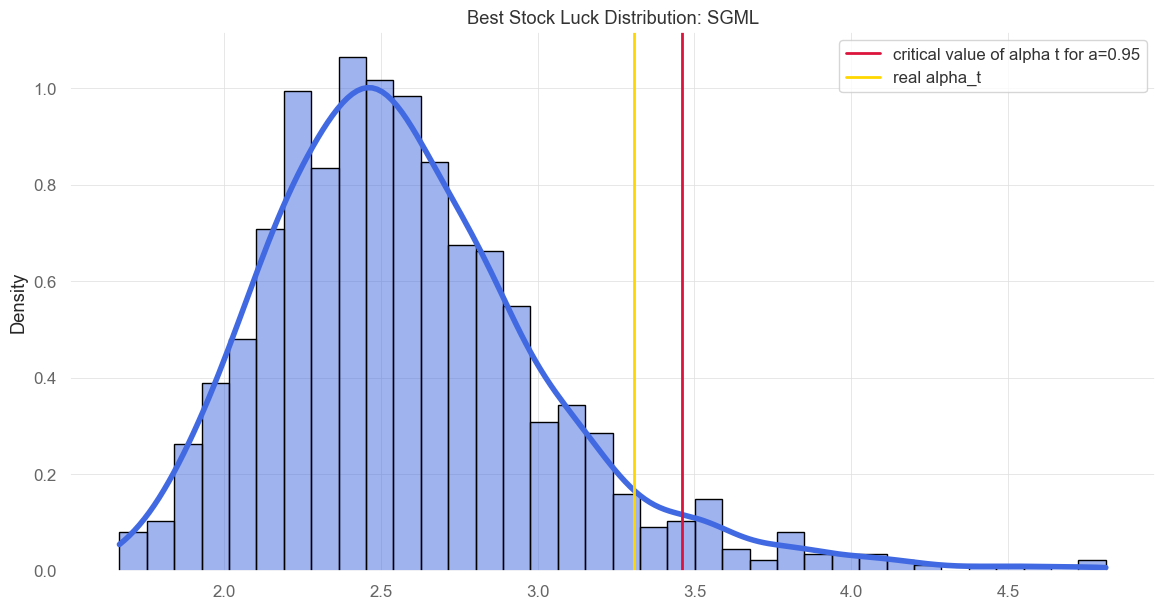

In [15]:
# Grafico luck distribution — titolo migliore (rank più alto)
luck_a = -1   # -1 = ultima colonna = rango più alto

plt.figure(figsize=(14, 7))
sns.histplot(sorted(luck_d.iloc[:, luck_a]),
             bins=int(180/5),
             color='royalblue',
             kde=True,
             stat='density',
             edgecolor='black',
             line_kws={'linewidth': 4})

plt.axvline(np.percentile(luck_d.iloc[:, luck_a], 95),
            label='critical value of alpha t for a=0.95',
            color='crimson', linewidth=2)
plt.axvline(sorted_original.iloc[luck_a, 0],
            label='real alpha_t',
            color='gold', linewidth=2)

plt.title(f"Best Stock Luck Distribution: {sorted_original.index[luck_a]}")
plt.legend()
plt.show()

Se nessun titolo avesse vera abilità, in 1000 simulazioni, quanto avrebbe ottenuto il titolo che arrivava primo in classifica?

Il risultato è che per pura fortuna il primo in classifica ottiene tipicamente un t-alpha intorno a 2.4-2.5. Quella è la "normale fortuna" di chi arriva primo tra 153 titoli.

Linea rossa (≈ 3.5) = 95° percentile della fortuna. Cioè: solo nel 5% delle simulazioni il primo arrivava per caso ad un t-alpha così alto. È la soglia.

Linea gialla (≈ 3.3) = t-alpha reale osservato di SGML

La linea gialla sta a sinistra della rossa. Significa che SGML, pur essendo il titolo migliore del campione, ha ottenuto un t-alpha che rientra ancora nel range della fortuna pura. Non è classificato come skilled — il suo risultato potrebbe essere spiegato dalla casualità.

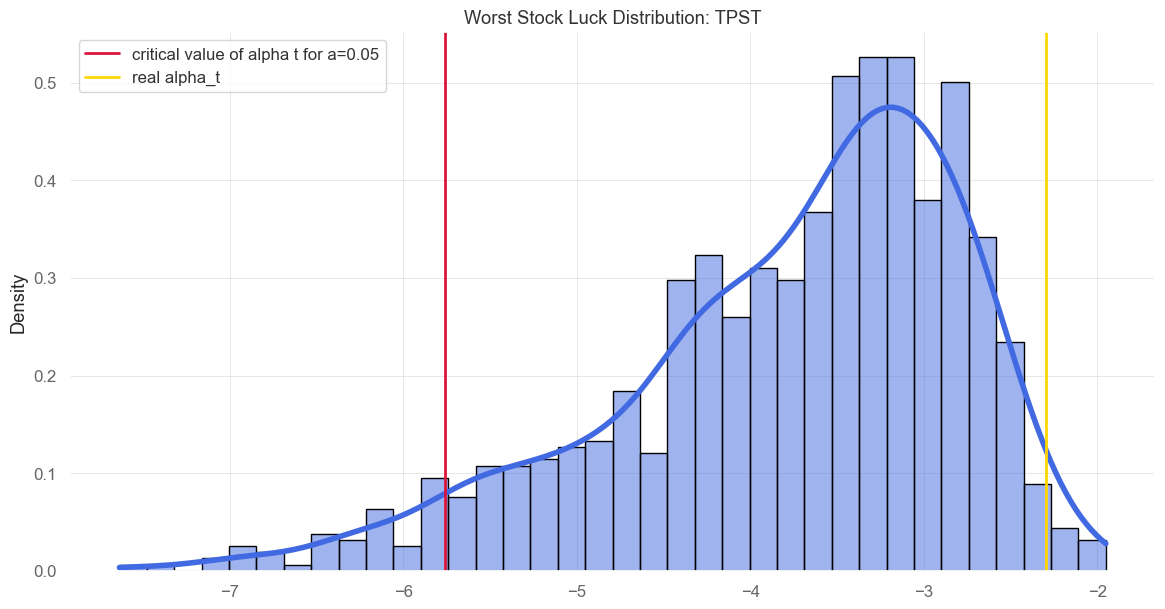

In [16]:
# Grafico luck distribution — titolo peggiore (rank più basso)
unluck_a = 0   # 0 = prima colonna = rango più basso

plt.figure(figsize=(14, 7))
sns.histplot(sorted(luck_d.iloc[:, unluck_a]),
             bins=int(180/5),
             color='royalblue',
             kde=True,
             stat='density',
             edgecolor='black',
             line_kws={'linewidth': 4})

plt.axvline(np.percentile(luck_d.iloc[:, unluck_a], 5),
            label='critical value of alpha t for a=0.05',
            color='crimson', linewidth=2)
plt.axvline(sorted_original.iloc[unluck_a, 0],
            label='real alpha_t',
            color='gold', linewidth=2)

plt.title(f"Worst Stock Luck Distribution: {sorted_original.index[unluck_a]}")
plt.legend()
plt.show()

In 1000 simulazioni, quanto avrebbe ottenuto il titolo che arrivava ultimo in classifica per pura sfortuna?

Per pura sfortuna, chi arriva ultimo ottiene tipicamente un t-alpha attorno a -3, -3.5. Quella è la distribuzione blu.

Linea rossa (≈ -5.9) = 5° percentile della sfortuna. Solo nel 5% delle simulazioni chi arrivava ultimo otteneva un t-alpha così negativo. È la soglia di "vera incapacità".

Linea gialla (≈ -2.1) = t-alpha reale osservato di TPST

La linea gialla sta molto a destra della rossa — cioè il suo t-alpha negativo è ampiamente dentro la distribuzione della sfortuna normale. TPST ha un alpha negativo, ma non abbastanza negativo da essere classificato come strutturalmente incapace. È semplicemente sfortunato, non incompetente.


## PUNTO 3

Sui fondi comuni, l'alpha misura la capacità del gestore di battere il mercato dopo i costi. 

Sui titoli azionari, l'alpha misura invece un'anomalia di prezzo rispetto ai fattori di rischio sistematici, non l'abilità di un gestore, ma l'inefficienza del mercato nel prezzare quel titolo.

La metodologia bootstrap rimane identica nei due casi, ma cambia  l'interpretazione del risultato. Nel caso dei fondi, un alpha persistente suggerisce che il gestore possiede una vera skill replicabile nel tempo. Nel caso dei titoli, suggerisce che il mercato ha sistematicamente  sottovalutato o sopravvalutato quel titolo nel periodo in-sample, un'anomalia che potrebbe non persistere una volta che il mercato la corregge.

Nel nostro campione, la luck distribution ha identificato 21 titoli  skilled su 153 analizzati, contro i soli 9 che il test OLS classico avrebbe selezionato.

il test OLS considera significativo qualunque titolo con t-alpha superiore a 1.645, indipendentemente da quanti titoli si stanno testando contemporaneamente. Su 153 titoli, questa soglia fissa produce inevitabilmente falsi positivi — titoli che sembrano bravi ma sono solo fortunati.

La luck distribution corregge questo problema. Dei 9 titoli selezionati dall'OLS, solo 3 vengono confermati anche dalla luck distribution. Gli altri 6 vengono smascherati: il loro t-alpha, per quanto alto in valore assoluto, rientra comunque in quello che ci si aspetterebbe per pura fortuna data la loro posizione in classifica. Sono i dropouts.

I restanti 18 titoli skilled (le additions) sono titoli che l'OLS ignorava perché non superavano la soglia fissa di 1.645, ma che la luck distribution promuove: la loro performance è sufficientemente estrema rispetto a ciò che la fortuna avrebbe prodotto a quel rango.

## PUNTO 4

In [17]:
rendimenti_is = data.loc['2017-01-01':'2022-12-31', skilled_tickers]
port_is = rendimenti_is.mean(axis=1).dropna()
port_is 
# 'port_is' è il ptf equal-weight
# ogni riga rappresenta il rendimento mensile del ptf, calcolato come media dei rendimenti dei 21 titoli skilled
# ogni titolo pesa 1/N

Date
2017-02-01     0.983707
2017-03-01     3.747795
2017-04-01     1.504283
2017-05-01     3.725277
2017-06-01     0.421522
                ...    
2022-08-01    -3.344919
2022-09-01    -5.326510
2022-10-01     7.700016
2022-11-01     4.998686
2022-12-01   -11.890085
Length: 71, dtype: float64

## COMMENTO 4
Il portafoglio è stato costruito con i 21 titoli che la luck distribution ha identificato come skilled sul periodo in-sample 2017-2022, con pesi uguali per tutti.

## PUNTO 5

In queste tre celle di seguitocostruiamo i rendimenti mensili out-of-sample del portafoglio anno per anno, applicando la logica del ribilanciamento annuale con finestra mobile di 6 anni (così come richiesto dalla consegna).

In [ ]:
# ANNO 2023 — portafoglio basato su skilled_tickers (finestra 2017-2022)
# non c'è nessun ricalcolo. Prendiamo direttamente i skilled_tickers identificati in-sample (finestra 2017–2022) 
# e calcoliamo semplicemente i rendimenti mensili di quei titoli durante il 2023, facendone la media equal-weight
rendimenti_2023 = full_data.loc['2023-01-01':'2023-12-31', skilled_tickers]
port_2023 = rendimenti_2023.mean(axis=1)

In [ ]:
# ANNO 2024 — nuova finestra 2018-2023, 500 iterazioni
data_2024 = full_data.loc['2018-01-01':'2023-12-31']

# bootstrap sulla nuova finestra: stessa logica del punto 2, meno iterazioni
np.random.seed(42)
alpha_obs_24, alpha_t_obs_24, alphas_boot_24, t_alphas_boot_24 = fm.bootstrap(
    data_2024.iloc[:, :n_factors],
    data_2024.iloc[:, n_factors:],
    n_boot=500,
    min_obs=36
)

# costruzione luck distribution: ordina le simulazioni per rango (colonna = posizione in classifica)
luck_d_24 = pd.DataFrame(np.sort(np.array(t_alphas_boot_24)))
luck_d_24.index = [f"sim_{i+1}" for i in range(len(luck_d_24))]

# ordina i t-alpha reali dal peggiore al migliore
sorted_original_24 = pd.DataFrame(alpha_t_obs_24.sort_values(ascending=True))

perc95_24 = pd.DataFrame(np.percentile(luck_d_24.T, 95, axis=1)).set_index(sorted_original_24.index)
luck_sig_24 = (sorted_original_24.iloc[:, 0] > perc95_24.iloc[:, 0]) & (sorted_original_24.iloc[:, 0] > 0)
skilled_list_24 = sorted_original_24[luck_sig_24]

# Fallback: se nessun titolo è significativo, usa il 95° percentile
if len(skilled_list_24) == 0:
    print("Nessun titolo skilled nel 2024 — mantengo composizione 2023")
    skilled_tickers_24 = skilled_tickers    # carry-forward dalla finestra precedente
else:
    skilled_tickers_24 = skilled_list_24.index.tolist()

print(f"Titoli skilled 2024: {len(skilled_tickers_24)}")

# Rendimenti 2024
rendimenti_2024 = full_data.loc['2024-01-01':'2024-12-31', skilled_tickers_24]
port_2024 = rendimenti_2024.mean(axis=1)

Nessun titolo skilled nel 2024 — mantengo composizione 2023
Titoli skilled 2024: 21


In [20]:
# ANNO 2025 — nuova finestra 2019-2024, 500 iterazioni
data_2025 = full_data.loc['2019-01-01':'2024-12-31']

np.random.seed(42)
alpha_obs_25, alpha_t_obs_25, alphas_boot_25, t_alphas_boot_25 = fm.bootstrap(
    data_2025.iloc[:, :n_factors],
    data_2025.iloc[:, n_factors:],
    n_boot=500,
    min_obs=36
)

# Luck distribution — stesso pattern
luck_d_25 = pd.DataFrame(np.sort(np.array(t_alphas_boot_25)))
luck_d_25.index = [f"sim_{i+1}" for i in range(len(luck_d_25))]

sorted_original_25 = pd.DataFrame(alpha_t_obs_25.sort_values(ascending=True))
perc95_25 = pd.DataFrame(np.percentile(luck_d_25.T, 95, axis=1)).set_index(sorted_original_25.index)
luck_sig_25 = (sorted_original_25.iloc[:, 0] > perc95_25.iloc[:, 0]) & (sorted_original_25.iloc[:, 0] > 0)
skilled_list_25 = sorted_original_25[luck_sig_25]

# Fallback
if len(skilled_list_25) == 0:
    print("Nessun titolo skilled nel 2025 — mantengo composizione 2024")
    skilled_tickers_25 = skilled_tickers_24
else:
    skilled_tickers_25 = skilled_list_25.index.tolist()

print(f"Titoli skilled 2025: {len(skilled_tickers_25)}")

# Rendimenti 2025
rendimenti_2025 = full_data.loc['2025-01-01':'2025-12-31', skilled_tickers_25]
port_2025 = rendimenti_2025.mean(axis=1)

Titoli skilled 2025: 2


In [21]:
# Accodiamo le tre serie — suggerimento dal testo dell'homework
port_oos = pd.concat([port_2023, port_2024, port_2025])
port_oos

Date
2023-01-01    18.634367
2023-02-01   -10.581332
2023-03-01    -5.409421
2023-04-01    -3.393310
2023-05-01    -4.525259
2023-06-01     3.518474
2023-07-01     9.931739
2023-08-01   -11.284728
2023-09-01   -11.092039
2023-10-01    -7.036684
2023-11-01     4.119747
2023-12-01    10.945307
2024-01-01    -8.946246
2024-02-01     1.487004
2024-03-01     5.258699
2024-04-01   -10.003921
2024-05-01     8.092386
2024-06-01    -2.550826
2024-07-01     2.522898
2024-08-01     1.547341
2024-09-01     2.334731
2024-10-01    -1.840857
2024-11-01     3.838482
2024-12-01    -2.916280
2025-01-01    23.948013
2025-02-01   -14.803684
2025-03-01   -16.500711
2025-04-01    20.089465
2025-05-01     2.201221
2025-06-01   -44.868126
2025-07-01    21.008218
2025-08-01    13.018787
2025-09-01   -11.246887
2025-10-01    38.595304
2025-11-01    -8.099445
2025-12-01   -19.617362
dtype: float64

## COMMENTO 5
Per il 2023 il portafoglio è rimasto quello dei 21 titoli della finestra in-sample. Per il 2024 la luck distribution sulla finestra 2018-2023 non ha trovato nessun titolo significativo, quindi la composizione è rimasta invariata. Per il 2025 la finestra 2019-2024 ha prodotto solo 2 titoli skilled, e il portafoglio è stato aggiornato con questi. Il fatto che nelle ultime due finestre la procedura trovi sempre meno titoli è già indicativo: l'alfa identificato in-sample tende a svanire man mano che la finestra si sposta in avanti.

## PUNTO 6

In [22]:
bench = yf.download('^IXIC', start = '2023-01-01', end = '2025-12-31',auto_adjust=False, multi_level_index=False, interval='1mo')['Adj Close']

bench

[*********************100%***********************]  1 of 1 completed


Date
2023-01-01    11584.549805
2023-02-01    11455.540039
2023-03-01    12221.910156
2023-04-01    12226.580078
2023-05-01    12935.290039
2023-06-01    13787.919922
2023-07-01    14346.019531
2023-08-01    14034.969727
2023-09-01    13219.320312
2023-10-01    12851.240234
2023-11-01    14226.219727
2023-12-01    15011.349609
2024-01-01    15164.009766
2024-02-01    16091.919922
2024-03-01    16379.459961
2024-04-01    15657.820312
2024-05-01    16735.019531
2024-06-01    17732.599609
2024-07-01    17599.400391
2024-08-01    17713.619141
2024-09-01    18189.169922
2024-10-01    18095.150391
2024-11-01    19218.169922
2024-12-01    19310.789062
2025-01-01    19627.439453
2025-02-01    18847.279297
2025-03-01    17299.289062
2025-04-01    17446.339844
2025-05-01    19113.769531
2025-06-01    20369.730469
2025-07-01    21122.449219
2025-08-01    21455.550781
2025-09-01    22660.009766
2025-10-01    23724.960938
2025-11-01    23365.689453
2025-12-01    23241.990234
Name: Adj Close, dtype:

In [23]:
bench_returns = bench.pct_change().dropna() * 100
bench_returns

Date
2023-02-01    -1.113636
2023-03-01     6.689952
2023-04-01     0.038209
2023-05-01     5.796469
2023-06-01     6.591502
2023-07-01     4.047743
2023-08-01    -2.168196
2023-09-01    -5.811551
2023-10-01    -2.784410
2023-11-01    10.699197
2023-12-01     5.518893
2024-01-01     1.016965
2024-02-01     6.119161
2024-03-01     1.786860
2024-04-01    -4.405760
2024-05-01     6.879624
2024-06-01     5.961033
2024-07-01    -0.751154
2024-08-01     0.648992
2024-09-01     2.684662
2024-10-01    -0.516898
2024-11-01     6.206191
2024-12-01     0.481935
2025-01-01     1.639759
2025-02-01    -3.974844
2025-03-01    -8.213335
2025-04-01     0.850039
2025-05-01     9.557476
2025-06-01     6.570975
2025-07-01     3.695281
2025-08-01     1.577003
2025-09-01     5.613741
2025-10-01     4.699694
2025-11-01    -1.514319
2025-12-01    -0.529405
Name: Adj Close, dtype: float64

In [24]:
factors_oos = fm.ff('F-F_Research_Data_Factors', '2023-01-01', '2025-12-31')[0]
rf_oos = factors_oos['RF']
rf_oos

Date
2023-01-01    0.35
2023-02-01    0.34
2023-03-01    0.36
2023-04-01    0.35
2023-05-01    0.36
2023-06-01    0.40
2023-07-01    0.45
2023-08-01    0.45
2023-09-01    0.43
2023-10-01    0.47
2023-11-01    0.44
2023-12-01    0.43
2024-01-01    0.47
2024-02-01    0.42
2024-03-01    0.43
2024-04-01    0.47
2024-05-01    0.44
2024-06-01    0.41
2024-07-01    0.45
2024-08-01    0.48
2024-09-01    0.40
2024-10-01    0.39
2024-11-01    0.40
2024-12-01    0.37
2025-01-01    0.37
2025-02-01    0.33
2025-03-01    0.34
2025-04-01    0.35
2025-05-01    0.38
2025-06-01    0.34
2025-07-01    0.34
2025-08-01    0.38
2025-09-01    0.33
2025-10-01    0.37
2025-11-01    0.30
2025-12-01    0.34
Name: RF, dtype: float64

In [25]:
er_port_oos = port_oos.dropna()
er_bench_oos = bench_returns.subtract(rf_oos, axis=0).dropna()

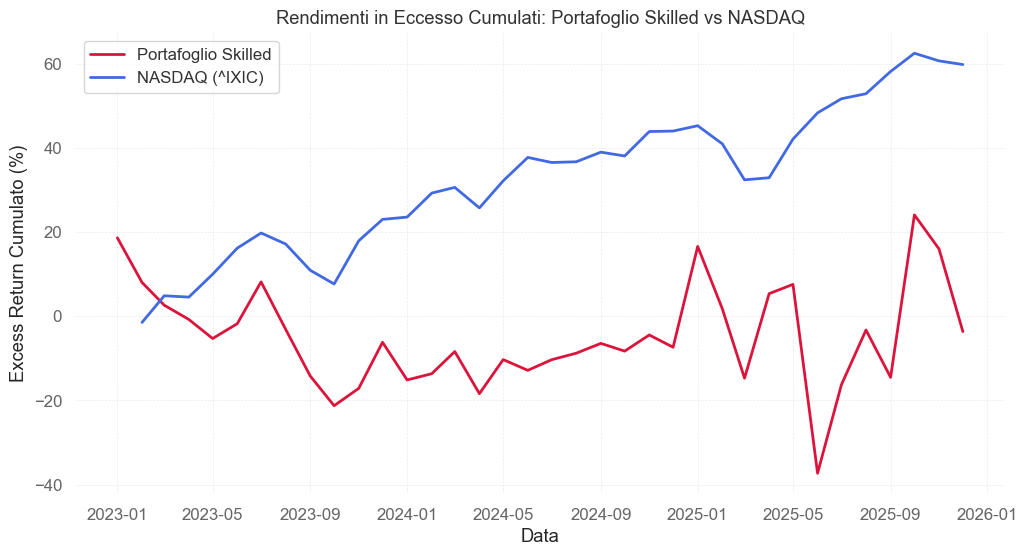

In [26]:
cum_port = er_port_oos.cumsum()
cum_bench = er_bench_oos.cumsum()

plt.figure(figsize=(12, 6))
plt.plot(cum_port, color='crimson', linewidth=2, label='Portafoglio Skilled')
plt.plot(cum_bench, color='royalblue', linewidth=2, label='NASDAQ (^IXIC)')
plt.title('Rendimenti in Eccesso Cumulati: Portafoglio Skilled vs NASDAQ')
plt.xlabel('Data')
plt.ylabel('Excess Return Cumulato (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## COMMENTO 6 
Il grafico mostra che il portafoglio skilled ha sottoperformato il NASDAQ per tutto il periodo out-of-sample. Il NASDAQ chiude i tre anni con un excess return cumulato intorno al 60%, mentre il portafoglio oscilla sostanzialmente attorno allo zero, con un picco negativo di circa -40% nella prima metà del 2025 e un parziale recupero finale.
Il risultato non sorprende più di tanto, ed è coerente con quello che già si intuiva dal ribilanciamento: la luck distribution ha faticato a trovare titoli significativi nelle finestre successive, segno che l'alfa identificato in-sample non era particolarmente persistente. In sostanza, i titoli che sembravano skilled nel periodo 2017-2022 non hanno continuato a battere il mercato una volta che la finestra si è spostata in avanti.
Va anche considerato che il NASDAQ nel triennio 2023-2025 è stato trainato in modo molto concentrato dai titoli legati all'intelligenza artificiale, una dinamica difficile da catturare con un portafoglio costruito su criteri di alfa storico. Un benchmark così particolare rende il confronto inevitabilmente sfavorevole per qualsiasi strategia di stock picking basata su periodi precedenti.